In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
## Step 1: Load and Preprocess Data
# Load training and test datasets
df_train = pd.read_csv('trainset.csv')
df_test = pd.read_csv('testset.csv')

In [3]:
# Use closing prices
train_prices = df_train['Close'].values.reshape(-1, 1)
test_prices = df_test['Close'].values.reshape(-1, 1)

In [4]:
# Normalize the data based on training set only
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train_prices)
scaled_test = scaler.transform(test_prices)

In [5]:
# Create sequences
def create_sequences(data, seq_length):
    x = []
    y = []
    for i in range(len(data) - seq_length):
        x.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(x), np.array(y)

seq_length = 60
x_train, y_train = create_sequences(scaled_train, seq_length)
x_test, y_test = create_sequences(scaled_test, seq_length)


In [6]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((1199, 60, 1), (1199, 1), (65, 60, 1), (65, 1))

In [7]:
# Convert to PyTorch tensors
x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)


In [8]:
# Create dataset and dataloader
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [9]:
## Step 2: Define RNN Model
class RNNModel(nn.Module):

    def __init__(
            self,
            input_size=1,
            hidden_size=50,
            num_layers=2,
            output_size=1):

        super(RNNModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc = nn.Linear( hidden_size, output_size )

    def forward(self, x):

        h0 = torch.zeros(
            self.num_layers,
            x.size(0),
            self.hidden_size
        ).to(x.device)

        out, _ = self.rnn(x, h0)

        out = out[:, -1, :]

        out = self.fc(out)

        return out

In [10]:
model = RNNModel()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [11]:
!pip install torchinfo

In [12]:
from torchinfo import summary

# input_size = (batch_size, seq_len, input_size)
summary(model, input_size=(64, 60, 1))

Layer (type:depth-idx)                   Output Shape              Param #
RNNModel                                 [64, 1]                   --
├─RNN: 1-1                               [64, 60, 50]              7,750
├─Linear: 1-2                            [64, 1]                   51
Total params: 7,801
Trainable params: 7,801
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 29.76
Input size (MB): 0.02
Forward/backward pass size (MB): 1.54
Params size (MB): 0.03
Estimated Total Size (MB): 1.58

In [13]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [14]:
## Step 3: Train the Model

num_epochs = 50

train_losses = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for inputs, targets in train_loader:

        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(
            outputs,
            targets
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = (
        running_loss /
        len(train_loader)
    )

    train_losses.append(epoch_loss)

    print( f"Epoch [{epoch+1}/{num_epochs}] " f"Loss: {epoch_loss:.6f}" )

Epoch [1/50] Loss: 0.083997
Epoch [2/50] Loss: 0.029113
Epoch [3/50] Loss: 0.002776
Epoch [4/50] Loss: 0.000844
Epoch [5/50] Loss: 0.000536
Epoch [6/50] Loss: 0.000502
Epoch [7/50] Loss: 0.000452
Epoch [8/50] Loss: 0.000435
Epoch [9/50] Loss: 0.000436
Epoch [10/50] Loss: 0.000402
Epoch [11/50] Loss: 0.000392
Epoch [12/50] Loss: 0.000364
Epoch [13/50] Loss: 0.000372
Epoch [14/50] Loss: 0.000380
Epoch [15/50] Loss: 0.000357
Epoch [16/50] Loss: 0.000347
Epoch [17/50] Loss: 0.000325
Epoch [18/50] Loss: 0.000306
Epoch [19/50] Loss: 0.000311
Epoch [20/50] Loss: 0.000308
Epoch [21/50] Loss: 0.000334
Epoch [22/50] Loss: 0.000398
Epoch [23/50] Loss: 0.000375
Epoch [24/50] Loss: 0.000319
Epoch [25/50] Loss: 0.000295
Epoch [26/50] Loss: 0.000313
Epoch [27/50] Loss: 0.000303
Epoch [28/50] Loss: 0.000280
Epoch [29/50] Loss: 0.000272
Epoch [30/50] Loss: 0.000291
Epoch [31/50] Loss: 0.000277
Epoch [32/50] Loss: 0.000274
Epoch [33/50] Loss: 0.000291
Epoch [34/50] Loss: 0.000255
Epoch [35/50] Loss: 0.0

Name: Arunsamy D
Register Number: 212224240016


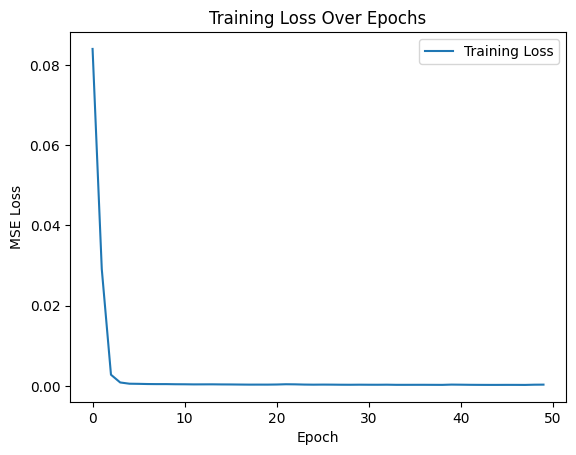

In [15]:
# Plot training loss
print('Name: Arunsamy D')
print('Register Number: 212224240016')
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.show()


Name:                 
Register Number:     


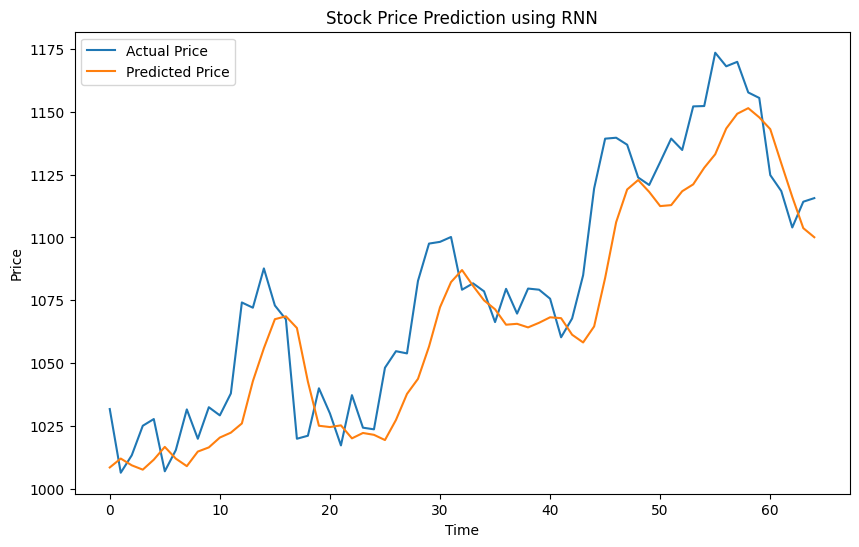

Predicted Price: [1100.0991]
Actual Price: [1115.65]


In [16]:
## Step 4: Make Predictions on Test Set
model.eval()
with torch.no_grad():
    predicted = model(x_test_tensor.to(device)).cpu().numpy()
    actual = y_test_tensor.cpu().numpy()

# Inverse transform the predictions and actual values
predicted_prices = scaler.inverse_transform(predicted)
actual_prices = scaler.inverse_transform(actual)

# Plot the predictions vs actual prices
print('Name:                 ')
print('Register Number:     ')
plt.figure(figsize=(10, 6))
plt.plot(actual_prices, label='Actual Price')
plt.plot(predicted_prices, label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Stock Price Prediction using RNN')
plt.legend()
plt.show()
print(f'Predicted Price: {predicted_prices[-1]}')
print(f'Actual Price: {actual_prices[-1]}')

In [18]:
from sklearn.metrics import r2_score

r2 = r2_score(
    actual_prices,
    predicted_prices
)

print("R² Score =", r2)

R² Score = 0.7846958041191101
